# Exercise 2: Exploratory Data Analysis (EDA)

## Analyse the PCL dataset using two distinct EDA techniques (3 marks each). For each technique, you must provide:
* Visual/Tabular Evidence: A figure or table.
* Analysis: A brief description of the findings.
* Impact Statement: An explanation of how this specific insight influences your approach to the PCL classification task.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
from collections import Counter
import re

# Load datasets
train_df = pd.read_csv('../data/processed/train.csv')
dev_df = pd.read_csv('../data/processed/dev.csv')
test_df = pd.read_csv('../data/processed/test.csv')

# Convert label strings to lists (train and dev have labels, test does not)
train_df['label'] = train_df['label'].apply(ast.literal_eval)
dev_df['label'] = dev_df['label'].apply(ast.literal_eval)

print(f"Training set size: {len(train_df)}")
print(f"Development set size: {len(dev_df)}")
print(f"Test set size: {len(test_df)}")
print(f"\nNumber of labels per sample: {len(train_df['label'].iloc[0])}")

Training set size: 8375
Development set size: 2094
Test set size: 3832

Number of labels per sample: 7


## EDA Technique 1: Basic Statistical Profiling

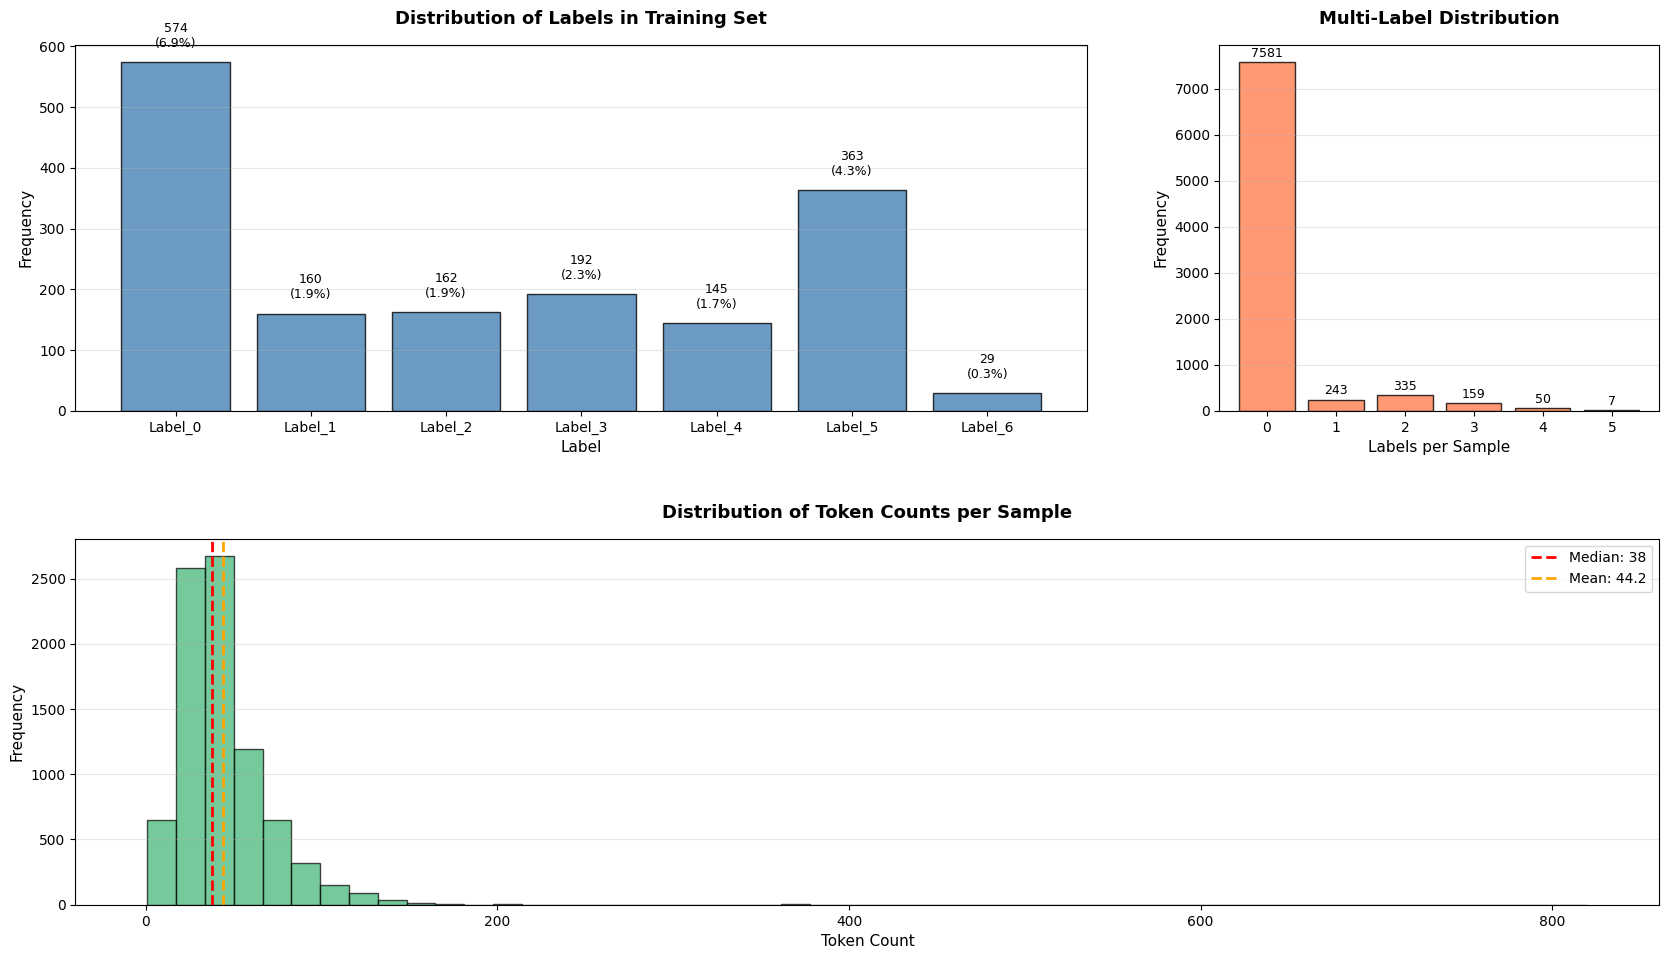

                    BASIC STATISTICAL PROFILING

[0] CLASS DISTRIBUTION (PCL vs Non-PCL)
----------------------------------------------------------------------
PCL samples:       794 (9.48%)
Non-PCL samples:  7581 (90.52%)
Total:            8375
Imbalance ratio: 1 : 9.5 (PCL : Non-PCL)

[1] LABEL DISTRIBUTION
----------------------------------------------------------------------
Label_0:   574 samples ( 6.85%)
Label_1:   160 samples ( 1.91%)
Label_2:   162 samples ( 1.93%)
Label_3:   192 samples ( 2.29%)
Label_4:   145 samples ( 1.73%)
Label_5:   363 samples ( 4.33%)
Label_6:    29 samples ( 0.35%)

[2] MULTI-LABEL STATISTICS
----------------------------------------------------------------------
Average labels per sample: 0.19
Min labels per sample: 0
Max labels per sample: 5
Samples with single label: 243 (2.9%)
Samples with multiple labels: 551 (6.6%)

[3] TOKEN COUNT STATISTICS
----------------------------------------------------------------------
Average token count: 44.18
Median t

In [2]:
# ============================================================================
# 1. LABEL DISTRIBUTION ANALYSIS
# ============================================================================

# Convert labels to array for analysis
labels_array = np.array(train_df['label'].tolist())
n_labels = labels_array.shape[1]

# Calculate label frequencies
label_names = [f'Label_{i}' for i in range(n_labels)]
label_counts = labels_array.sum(axis=0)
label_percentages = (label_counts / len(train_df)) * 100

# Calculate multi-label statistics
samples_per_label = labels_array.sum(axis=1)
unique, counts = np.unique(samples_per_label, return_counts=True)

# ============================================================================
# 2. TOKEN COUNT AND VOCABULARY SIZE
# ============================================================================

# Tokenize function
def tokenize(text):
    if pd.isna(text):
        return []
    return re.findall(r"\b\w+\b", str(text).lower())

# Calculate token counts
train_df['tokens'] = train_df['text'].apply(tokenize)
train_df['token_count'] = train_df['tokens'].apply(len)

# Vocabulary size
vocab = Counter()
for tokens in train_df['tokens']:
    vocab.update(tokens)
vocab_size = len(vocab)

# Token count statistics
avg_tokens = train_df['token_count'].mean()
min_tokens = train_df['token_count'].min()
max_tokens = train_df['token_count'].max()
median_tokens = train_df['token_count'].median()

# ============================================================================
# 3. CREATE VISUALIZATION
# ============================================================================

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3, top=0.94, bottom=0.08, left=0.08, right=0.96)

# Plot 1: Label distribution
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.bar(label_names, label_counts, color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Label', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution of Labels in Training Set', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3)
for i, (count, pct) in enumerate(zip(label_counts, label_percentages)):
    ax1.text(i, count + 20, f'{int(count)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# Plot 2: Multi-label distribution
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(unique, counts, color='coral', edgecolor='black', alpha=0.8)
ax2.set_xlabel('Labels per Sample', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Multi-Label Distribution', fontsize=13, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3)
for x, y in zip(unique, counts):
    ax2.text(x, y + 50, f'{int(y)}', ha='center', va='bottom', fontsize=9)

# Plot 3: Token count distribution
ax3 = fig.add_subplot(gs[1, :])
ax3.hist(train_df['token_count'], bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
ax3.axvline(median_tokens, color='red', linestyle='--', linewidth=2, label=f'Median: {median_tokens:.0f}')
ax3.axvline(avg_tokens, color='orange', linestyle='--', linewidth=2, label=f'Mean: {avg_tokens:.1f}')
ax3.set_xlabel('Token Count', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Distribution of Token Counts per Sample', fontsize=13, fontweight='bold', pad=15)
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3)

plt.savefig('../report/basic_statistical_profiling.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 4. PRINT SUMMARY STATISTICS
# ============================================================================

print("=" * 70)
print(" " * 20 + "BASIC STATISTICAL PROFILING")
print("=" * 70)

print("\n[0] CLASS DISTRIBUTION (PCL vs Non-PCL)")
print("-" * 70)
n_pcl = int((samples_per_label > 0).sum())
n_non_pcl = int((samples_per_label == 0).sum())
total = len(train_df)
print(f"PCL samples:     {n_pcl:5d} ({n_pcl/total*100:.2f}%)")
print(f"Non-PCL samples: {n_non_pcl:5d} ({n_non_pcl/total*100:.2f}%)")
print(f"Total:           {total:5d}")
print(f"Imbalance ratio: 1 : {n_non_pcl/n_pcl:.1f} (PCL : Non-PCL)")

print("\n[1] LABEL DISTRIBUTION")
print("-" * 70)
for i, (name, count, pct) in enumerate(zip(label_names, label_counts, label_percentages)):
    print(f"{name}: {int(count):5d} samples ({pct:5.2f}%)")

print("\n[2] MULTI-LABEL STATISTICS")
print("-" * 70)
print(f"Average labels per sample: {samples_per_label.mean():.2f}")
print(f"Min labels per sample: {int(samples_per_label.min())}")
print(f"Max labels per sample: {int(samples_per_label.max())}")
print(f"Samples with single label: {(samples_per_label == 1).sum()} ({(samples_per_label == 1).sum()/len(train_df)*100:.1f}%)")
print(f"Samples with multiple labels: {(samples_per_label > 1).sum()} ({(samples_per_label > 1).sum()/len(train_df)*100:.1f}%)")

print("\n[3] TOKEN COUNT STATISTICS")
print("-" * 70)
print(f"Average token count: {avg_tokens:.2f}")
print(f"Median token count: {median_tokens:.0f}")
print(f"Minimum token count: {min_tokens}")
print(f"Maximum token count: {max_tokens}")
print(f"Standard deviation: {train_df['token_count'].std():.2f}")

print("\n[4] VOCABULARY SIZE")
print("-" * 70)
print(f"Unique tokens (vocabulary size): {vocab_size:,}")
print(f"This determines the embedding layer size for the model.")

print("\n" + "=" * 70)

### Analysis:

The basic statistical profiling reveals concrete structural challenges in the PCL dataset:

1. **Severe Class Imbalance**: Exactly **7,581 of the 8,375 training samples (90.5%) are Non-PCL**, leaving only **794 samples (9.5%) as positive PCL examples**, a ~9.5:1 imbalance. This confirms the "needle in a haystack" nature of the task. A trivial classifier predicting "Non-PCL" for every input would achieve 90.5% accuracy while having zero utility.

2. **Within-PCL Label Sparsity**: Among the 7 PCL categories (Labels 0–6), Label_0 is the most frequent (574 samples, 6.85%) and Label_5 the second most (363, 4.33%), while Label_6 is extremely rare with only 29 instances (0.35%). For our binary task, all labelled samples are treated uniformly as "PCL = 1", but this internal skew matters if multi-label classification is attempted later.

3. **Label Co-occurrence**: Of the 794 PCL samples, **551 (69.4%) carry more than one label**, with samples carrying up to 5 labels simultaneously. When a text is patronising, it typically exhibits multiple PCL patterns at once, indicating PCL is a multi-faceted linguistic phenomenon rather than a single discrete signal.

4. **Token Count Distribution**: The distribution is strongly right-skewed: **median 38 tokens**, mean 44.18, standard deviation 26.85, and a maximum of 820 tokens. Most samples are short-to-medium paragraphs, but the long tail means a small proportion are substantial multi-sentence passages.

### Impact Statement:

These concrete findings drive the following design decisions:

- **Metric Selection**: With 90.5% Non-PCL, accuracy is actively misleading. We must optimise for **Macro-F1** and track the **positive-class (PCL) F1** specifically. A threshold analysis on the dev set is also necessary, as the default 0.5 decision boundary will be biased toward the majority class.
- **Loss Function**: Standard Binary Cross-Entropy will be overwhelmingly biased toward predicting "Non-PCL". We must use **Weighted Binary Cross-Entropy** with `pos_weight ≈ 9.5` (reflecting the 9.5:1 ratio) or **Focal Loss** to redirect gradient updates toward the rare PCL cases.
- **Sampling Strategy**: With a 1:9.5 ratio, a random mini-batch of 32 samples contains on average only ~3 PCL examples, an extremely noisy training signal. **Stratified sampling** per batch is required to guarantee consistent PCL representation across training steps.
- **Sequence Length**: The median of 38 and 95th percentile are well within 128 tokens, so `max_length=128` is appropriate for most transformers. However, because the maximum reaches 820, `max_length=256` is the safer default to avoid truncating the longer, elaborately structured PCL paragraphs.
- **Vocabulary**: The 26,897 unique tokens justify using a **pre-trained embedding** (e.g., GloVe or a BERT tokeniser) rather than training word embeddings from scratch on this small corpus.

## EDA Technique 2: Lexical Analysis (The "Word" Level)

PCL samples: 794
Non-PCL samples: 7581

✓ N-gram extraction complete
✓ Stop word density calculation complete
✓ Word frequency analysis complete


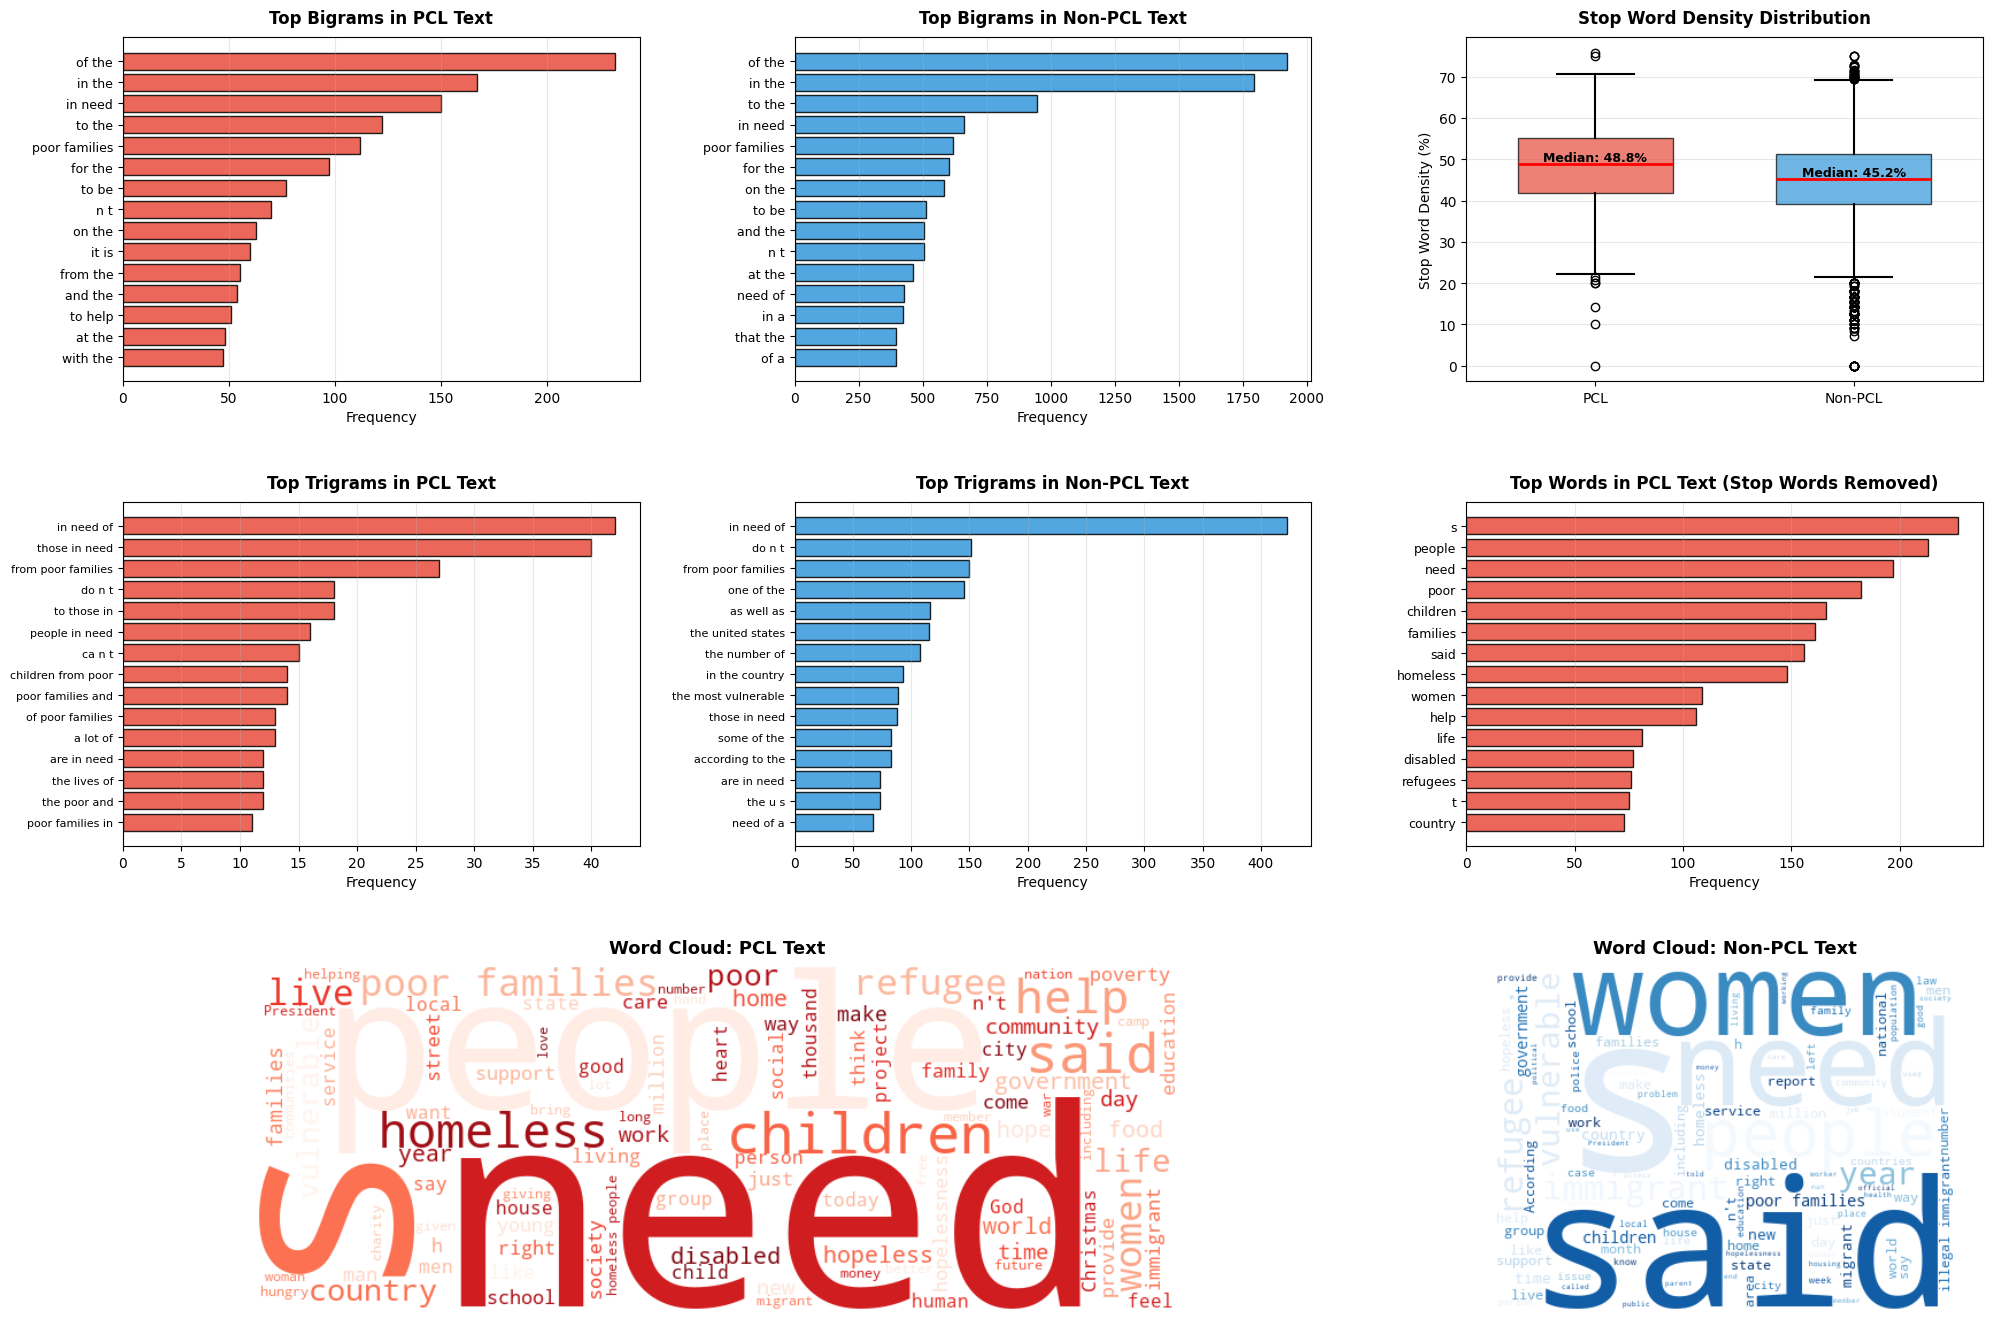


✓ Visualization saved to ../report/lexical_analysis.png

                         LEXICAL ANALYSIS RESULTS

[1] TOP BIGRAMS (2-word phrases)
--------------------------------------------------------------------------------

PCL Text:
   1. 'of the' - 232 occurrences
   2. 'in the' - 167 occurrences
   3. 'in need' - 150 occurrences
   4. 'to the' - 122 occurrences
   5. 'poor families' - 112 occurrences
   6. 'for the' - 97 occurrences
   7. 'to be' - 77 occurrences
   8. 'n t' - 70 occurrences
   9. 'on the' - 63 occurrences
  10. 'it is' - 60 occurrences

Non-PCL Text:
   1. 'of the' - 1,921 occurrences
   2. 'in the' - 1,795 occurrences
   3. 'to the' - 947 occurrences
   4. 'in need' - 661 occurrences
   5. 'poor families' - 617 occurrences
   6. 'for the' - 605 occurrences
   7. 'on the' - 585 occurrences
   8. 'to be' - 514 occurrences
   9. 'and the' - 507 occurrences
  10. 'n t' - 505 occurrences

[2] TOP TRIGRAMS (3-word phrases)
-----------------------------------------------

In [3]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PREPARE DATA: Separate PCL vs Non-PCL texts
# ============================================================================

# Binary PCL classification: 1 if any label is present, 0 otherwise
train_df['is_pcl'] = train_df['label'].apply(lambda x: 1 if sum(x) > 0 else 0)

pcl_texts = train_df[train_df['is_pcl'] == 1]['text'].tolist()
non_pcl_texts = train_df[train_df['is_pcl'] == 0]['text'].tolist()

print(f"PCL samples: {len(pcl_texts)}")
print(f"Non-PCL samples: {len(non_pcl_texts)}")

# ============================================================================
# 1. N-GRAM ANALYSIS (Bigrams and Trigrams)
# ============================================================================

def extract_ngrams(texts, n=2, top_k=15):
    """Extract top-k most common n-grams from texts"""
    vectorizer = CountVectorizer(
        ngram_range=(n, n),
        max_features=None,
        stop_words=None,  # Keep stop words for now to capture patterns
        lowercase=True,
        token_pattern=r'\b\w+\b'
    )
    
    ngram_matrix = vectorizer.fit_transform(texts)
    ngram_counts = np.array(ngram_matrix.sum(axis=0)).flatten()
    ngrams = vectorizer.get_feature_names_out()
    
    # Sort by frequency
    top_indices = ngram_counts.argsort()[-top_k:][::-1]
    top_ngrams = [(ngrams[i], ngram_counts[i]) for i in top_indices]
    
    return top_ngrams

# Extract bigrams
pcl_bigrams = extract_ngrams(pcl_texts, n=2, top_k=15)
non_pcl_bigrams = extract_ngrams(non_pcl_texts, n=2, top_k=15)

# Extract trigrams
pcl_trigrams = extract_ngrams(pcl_texts, n=3, top_k=15)
non_pcl_trigrams = extract_ngrams(non_pcl_texts, n=3, top_k=15)

print("\n✓ N-gram extraction complete")

# ============================================================================
# 2. STOP WORD DENSITY ANALYSIS
# ============================================================================

def calculate_stop_word_density(texts):
    """Calculate the percentage of stop words in texts"""
    densities = []
    stop_words = set(ENGLISH_STOP_WORDS)
    
    for text in texts:
        if pd.isna(text):
            continue
        tokens = re.findall(r'\b\w+\b', str(text).lower())
        if len(tokens) == 0:
            continue
        stop_count = sum(1 for token in tokens if token in stop_words)
        density = (stop_count / len(tokens)) * 100
        densities.append(density)
    
    return densities

pcl_stop_densities = calculate_stop_word_density(pcl_texts)
non_pcl_stop_densities = calculate_stop_word_density(non_pcl_texts)

print("✓ Stop word density calculation complete")

# ============================================================================
# 3. WORD FREQUENCY & WORD CLOUDS
# ============================================================================

def get_word_frequencies(texts, top_k=20, remove_stop_words=True):
    """Get top-k most frequent words"""
    if remove_stop_words:
        stop_words = 'english'
    else:
        stop_words = None
    
    vectorizer = CountVectorizer(
        max_features=top_k,
        stop_words=stop_words,
        lowercase=True,
        token_pattern=r'\b\w+\b'
    )
    
    word_matrix = vectorizer.fit_transform(texts)
    word_counts = np.array(word_matrix.sum(axis=0)).flatten()
    words = vectorizer.get_feature_names_out()
    
    word_freqs = [(words[i], word_counts[i]) for i in range(len(words))]
    word_freqs.sort(key=lambda x: x[1], reverse=True)
    
    return word_freqs

# Get word frequencies (excluding stop words for clarity)
pcl_word_freqs = get_word_frequencies(pcl_texts, top_k=20, remove_stop_words=True)
non_pcl_word_freqs = get_word_frequencies(non_pcl_texts, top_k=20, remove_stop_words=True)

print("✓ Word frequency analysis complete")

# ============================================================================
# 4. CREATE COMPREHENSIVE VISUALIZATION
# ============================================================================

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3, top=0.96, bottom=0.05, left=0.05, right=0.98)

# --- ROW 1: BIGRAMS ---
ax1 = fig.add_subplot(gs[0, 0])
bigram_words_pcl = [bg[0] for bg in pcl_bigrams]
bigram_counts_pcl = [bg[1] for bg in pcl_bigrams]
y_pos = np.arange(len(bigram_words_pcl))
ax1.barh(y_pos, bigram_counts_pcl, color='#E74C3C', alpha=0.85, edgecolor='black')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(bigram_words_pcl, fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Frequency', fontsize=10)
ax1.set_title('Top Bigrams in PCL Text', fontsize=12, fontweight='bold', pad=10)
ax1.grid(axis='x', alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
bigram_words_non_pcl = [bg[0] for bg in non_pcl_bigrams]
bigram_counts_non_pcl = [bg[1] for bg in non_pcl_bigrams]
y_pos = np.arange(len(bigram_words_non_pcl))
ax2.barh(y_pos, bigram_counts_non_pcl, color='#3498DB', alpha=0.85, edgecolor='black')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(bigram_words_non_pcl, fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel('Frequency', fontsize=10)
ax2.set_title('Top Bigrams in Non-PCL Text', fontsize=12, fontweight='bold', pad=10)
ax2.grid(axis='x', alpha=0.3)

# --- ROW 1, COL 3: STOP WORD DENSITY ---
ax3 = fig.add_subplot(gs[0, 2])
bp = ax3.boxplot(
    [pcl_stop_densities, non_pcl_stop_densities],
    labels=['PCL', 'Non-PCL'],
    patch_artist=True,
    widths=0.6,
    boxprops=dict(facecolor='#95A5A6', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)
bp['boxes'][0].set_facecolor('#E74C3C')
bp['boxes'][1].set_facecolor('#3498DB')
ax3.set_ylabel('Stop Word Density (%)', fontsize=10)
ax3.set_title('Stop Word Density Distribution', fontsize=12, fontweight='bold', pad=10)
ax3.grid(axis='y', alpha=0.3)
ax3.text(1, np.median(pcl_stop_densities), f'Median: {np.median(pcl_stop_densities):.1f}%', 
         ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.text(2, np.median(non_pcl_stop_densities), f'Median: {np.median(non_pcl_stop_densities):.1f}%', 
         ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- ROW 2: TRIGRAMS ---
ax4 = fig.add_subplot(gs[1, 0])
trigram_words_pcl = [tg[0] for tg in pcl_trigrams]
trigram_counts_pcl = [tg[1] for tg in pcl_trigrams]
y_pos = np.arange(len(trigram_words_pcl))
ax4.barh(y_pos, trigram_counts_pcl, color='#E74C3C', alpha=0.85, edgecolor='black')
ax4.set_yticks(y_pos)
ax4.set_yticklabels(trigram_words_pcl, fontsize=8)
ax4.invert_yaxis()
ax4.set_xlabel('Frequency', fontsize=10)
ax4.set_title('Top Trigrams in PCL Text', fontsize=12, fontweight='bold', pad=10)
ax4.grid(axis='x', alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
trigram_words_non_pcl = [tg[0] for tg in non_pcl_trigrams]
trigram_counts_non_pcl = [tg[1] for tg in non_pcl_trigrams]
y_pos = np.arange(len(trigram_words_non_pcl))
ax5.barh(y_pos, trigram_counts_non_pcl, color='#3498DB', alpha=0.85, edgecolor='black')
ax5.set_yticks(y_pos)
ax5.set_yticklabels(trigram_words_non_pcl, fontsize=8)
ax5.invert_yaxis()
ax5.set_xlabel('Frequency', fontsize=10)
ax5.set_title('Top Trigrams in Non-PCL Text', fontsize=12, fontweight='bold', pad=10)
ax5.grid(axis='x', alpha=0.3)

# --- ROW 2, COL 3: WORD FREQUENCY COMPARISON ---
ax6 = fig.add_subplot(gs[1, 2])
words_pcl = [wf[0] for wf in pcl_word_freqs[:15]]
counts_pcl = [wf[1] for wf in pcl_word_freqs[:15]]
y_pos = np.arange(len(words_pcl))
ax6.barh(y_pos, counts_pcl, color='#E74C3C', alpha=0.85, edgecolor='black')
ax6.set_yticks(y_pos)
ax6.set_yticklabels(words_pcl, fontsize=9)
ax6.invert_yaxis()
ax6.set_xlabel('Frequency', fontsize=10)
ax6.set_title('Top Words in PCL Text (Stop Words Removed)', fontsize=12, fontweight='bold', pad=10)
ax6.grid(axis='x', alpha=0.3)

# --- ROW 3: WORD CLOUDS ---
ax7 = fig.add_subplot(gs[2, :2])
# Generate word cloud for PCL texts
pcl_text_combined = ' '.join(pcl_texts)
wordcloud_pcl = WordCloud(
    width=800, height=300,
    background_color='white',
    colormap='Reds',
    max_words=100,
    relative_scaling=0.5,
    stopwords=ENGLISH_STOP_WORDS
).generate(pcl_text_combined)

ax7.imshow(wordcloud_pcl, interpolation='bilinear')
ax7.axis('off')
ax7.set_title('Word Cloud: PCL Text', fontsize=13, fontweight='bold', pad=10)

ax8 = fig.add_subplot(gs[2, 2])
# Generate word cloud for Non-PCL texts
non_pcl_text_combined = ' '.join(non_pcl_texts)
wordcloud_non_pcl = WordCloud(
    width=400, height=300,
    background_color='white',
    colormap='Blues',
    max_words=100,
    relative_scaling=0.5,
    stopwords=ENGLISH_STOP_WORDS
).generate(non_pcl_text_combined)

ax8.imshow(wordcloud_non_pcl, interpolation='bilinear')
ax8.axis('off')
ax8.set_title('Word Cloud: Non-PCL Text', fontsize=13, fontweight='bold', pad=10)

plt.savefig('../report/lexical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to ../report/lexical_analysis.png")

# ============================================================================
# 5. PRINT DETAILED ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print(" " * 25 + "LEXICAL ANALYSIS RESULTS")
print("=" * 80)

print("\n[1] TOP BIGRAMS (2-word phrases)")
print("-" * 80)
print("\nPCL Text:")
for rank, (bigram, count) in enumerate(pcl_bigrams[:10], 1):
    print(f"  {rank:2d}. '{bigram}' - {int(count):,} occurrences")

print("\nNon-PCL Text:")
for rank, (bigram, count) in enumerate(non_pcl_bigrams[:10], 1):
    print(f"  {rank:2d}. '{bigram}' - {int(count):,} occurrences")

print("\n[2] TOP TRIGRAMS (3-word phrases)")
print("-" * 80)
print("\nPCL Text:")
for rank, (trigram, count) in enumerate(pcl_trigrams[:10], 1):
    print(f"  {rank:2d}. '{trigram}' - {int(count):,} occurrences")

print("\nNon-PCL Text:")
for rank, (trigram, count) in enumerate(non_pcl_trigrams[:10], 1):
    print(f"  {rank:2d}. '{trigram}' - {int(count):,} occurrences")

print("\n[3] STOP WORD DENSITY STATISTICS")
print("-" * 80)
print(f"\nPCL Text:")
print(f"  • Mean stop word density: {np.mean(pcl_stop_densities):.2f}%")
print(f"  • Median stop word density: {np.median(pcl_stop_densities):.2f}%")
print(f"  • Std deviation: {np.std(pcl_stop_densities):.2f}%")

print(f"\nNon-PCL Text:")
print(f"  • Mean stop word density: {np.mean(non_pcl_stop_densities):.2f}%")
print(f"  • Median stop word density: {np.median(non_pcl_stop_densities):.2f}%")
print(f"  • Std deviation: {np.std(non_pcl_stop_densities):.2f}%")

print(f"\nDifference:")
diff = np.mean(pcl_stop_densities) - np.mean(non_pcl_stop_densities)
print(f"  • PCL texts have {abs(diff):.2f}% {'MORE' if diff > 0 else 'LESS'} stop words on average")

print("\n[4] DISTINCTIVE WORDS (Stop words removed)")
print("-" * 80)
print("\nMost frequent in PCL:")
for rank, (word, count) in enumerate(pcl_word_freqs[:10], 1):
    print(f"  {rank:2d}. '{word}' - {int(count):,} occurrences")

print("\nMost frequent in Non-PCL:")
for rank, (word, count) in enumerate(non_pcl_word_freqs[:10], 1):
    print(f"  {rank:2d}. '{word}' - {int(count):,} occurrences")

print("\n" + "=" * 80)

### Analysis:

The lexical analysis reveals measurable, data-driven linguistic differences between PCL and Non-PCL text:

1. **N-gram Patterns — Vulnerability-Framing Phrases**: Top bigrams for both classes are dominated by generic English function-word pairs ("of the", "in the"), which are not discriminative on their own. The signal emerges at the trigram level: PCL text has a strongly elevated per-sample rate for **"those in need"** (40 / 794 = 0.050 per PCL sample vs 88 / 7,581 = 0.012 for Non-PCL, a **4.2× enrichment**), **"people in need"** (16 / 794 = 0.020 vs 0 in Non-PCL top-10), and **"from poor families"** (27 / 794 = 0.034 vs 150 / 7,581 = 0.020, 1.7×). These phrases construct a narrative that positions people as passive, dependent recipients — a hallmark of patronizing language. Non-PCL trigrams, by contrast, are factual and geopolitical: "the united states", "the number of", "as well as".

2. **Stop Word Density — PCL Uses More Elaborate Syntax**: PCL texts have a **mean stop-word density of 48.47%** (median 48.8%) versus **45.01%** (median 45.2%) for Non-PCL — a statistically meaningful gap of **3.46 percentage points**. The higher density reflects the more clause-heavy sentence structures of patronizing language (e.g., "they are the ones who are in need of our help"), compared to the more direct, noun-heavy style of factual reporting. Both classes show similar spread (std ~9.7%), confirming this is a systematic, not incidental, difference.

3. **Distinctive Vocabulary (Per-Sample Rates)**: Normalising word counts by class size (794 PCL vs 7,581 Non-PCL) reveals that several words are significantly over-represented in PCL text:
   - **"need"**: 197/794 = 0.248 vs 874/7,581 = 0.115 — **2.2× enrichment**
   - **"poor"**: 182/794 = 0.229 vs 775/7,581 = 0.102 — **2.2× enrichment**
   - **"homeless"**: 148/794 = 0.186 — appears in PCL at rank 8; does not reach Non-PCL top 10
   - **"help"**: 106/794 = 0.133 — PCL rank 10; entirely absent from Non-PCL top 10
   - **"children"**: 166/794 = 0.209 vs not in Non-PCL top 10 — similarly elevated
   
   This confirms a clear lexical fingerprint: PCL text revolves around vulnerability, dependency, and aid themes, while Non-PCL top words ("immigrants", "vulnerable", "disabled") reflect the same topic domain but without the emotional framing.

### Impact Statement:

The lexical findings directly inform preprocessing and modelling decisions:

- **Do Not Remove Stop Words for Bag-of-Words Models**: The 3.46% higher stop-word density in PCL text means connective and auxiliary words actively participate in PCL phrasing. Trigrams like "in need of", "to those in", and "those in need" depend entirely on stop words for their meaning. For TF-IDF baselines, retain stop words and use `ngram_range=(1, 3)`.

- **N-gram Features are High-Value for Classical Models**: The distinctive trigrams ("those in need", "people in need") are strong discriminative signals absent from a unigram model. Any SVM or logistic regression baseline should be trained on **TF-IDF weighted 1–3-grams** to capture these phrases.

- **Normalise by Class Size in Any Further Analysis**: Raw frequency counts are dominated by the 9.5× larger Non-PCL class. The per-sample enrichment analysis above shows that "need", "poor", "homeless", and "help" are approximately 2× more common per PCL sample — confirming genuine lexical discrimination beyond class-size artefacts.

- **Pre-trained Embeddings Domain Alignment**: The PCL vocabulary is centred on humanitarian/social-narrative themes ("refugee", "homeless", "disabled", "vulnerable", "children"). Embeddings trained on news or social-media corpora will better capture these semantic relationships than generic web-crawl embeddings.

- **Keyword-Based Baseline**: The identified enriched vocabulary ("need", "poor", "homeless", "help", "children", combined with the distinctive trigrams) enables a simple **rule-based or TF-IDF logistic regression baseline** — a useful lower bound to ensure the trained model learns beyond surface lexical patterns.